In [2]:
import pandas as pd
fr = pd.read_csv("/Users/qiyuezhang/Downloads/project/freMTPLfreq.csv")

In [ ]:
#Data analyze
fr.info()

In [93]:
#analyze if the policyid is unique
fr["PolicyID"].is_unique

True

In [94]:
fr.groupby("PolicyID").size().describe()

count    413169.0
mean          1.0
std           0.0
min           1.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
dtype: float64

In [5]:
fr.describe(include='all')

,PolicyID,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density
count,413169.000000,413169.000000,413169.000000,413169,413169.000000,413169.000000,413169,413169,413169,413169.000000
unique,NaN,NaN,NaN,12,NaN,NaN,7,2,10,NaN
top,NaN,NaN,NaN,f,NaN,NaN,"Renault, Nissan or Citroen",Regular,Centre,NaN
freq,NaN,NaN,NaN,95718,NaN,NaN,218200,207224,160601,NaN
mean,206585.000000,0.039163,0.561088,NaN,7.532404,45.319876,NaN,NaN,NaN,1985.153913
std,119271.761023,0.204053,0.369477,NaN,5.763011,14.328120,NaN,NaN,NaN,4776.254543
min,1.000000,0.000000,0.002732,NaN,0.000000,18.000000,NaN,NaN,NaN,2.000000
25%,103293.000000,0.000000,0.200000,NaN,3.000000,34.000000,NaN,NaN,NaN,67.000000
50%,206585.000000,0.000000,0.540000,NaN,7.000000,44.000000,NaN,NaN,NaN,287.000000
75%,309877.000000,0.000000,1.000000,NaN,12.000000,54.000000,NaN,NaN,NaN,1410.000000


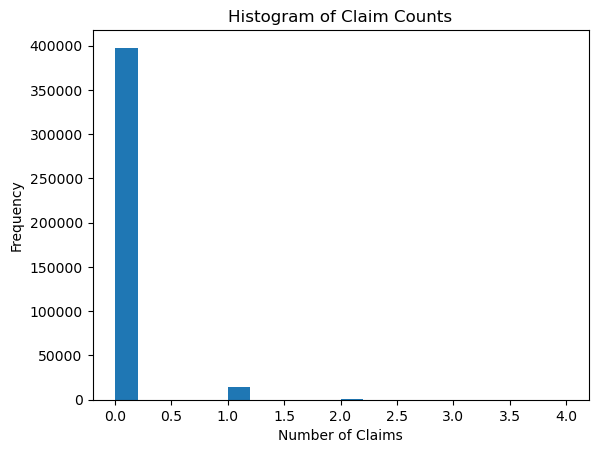

(np.float64(0.03916315115606447), 0.04163754465805693)

In [304]:
#the distribution of response(claimnb)
import matplotlib.pyplot as plt
plt.hist(fr["ClaimNb"], bins=20)
plt.xlabel("Number of Claims")
plt.ylabel("Frequency")
plt.title("Histogram of Claim Counts")
plt.show()
mean_nb = fr["ClaimNb"].mean()
var_nb  = fr["ClaimNb"].var()
mean_nb, var_nb

In [330]:
#variable analysis and grouping
fr['DriverAgeBand'] = pd.cut(fr['DriverAge'], bins = [17, 25, 35, 45, 55, 65, 100], right = True)
(fr.groupby("DriverAgeBand")["Exposure"].sum()
 / fr["Exposure"].sum())

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/2336601638.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (fr.groupby("DriverAgeBand")["Exposure"].sum()


DriverAgeBand
(17, 25]     0.048175
(25, 35]     0.194116
(35, 45]     0.242423
(45, 55]     0.250322
(55, 65]     0.137129
(65, 100]    0.127836
Name: Exposure, dtype: float64

In [331]:
fr.groupby("DriverAgeBand").apply(
    lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/3069600605.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fr.groupby("DriverAgeBand").apply(
/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/3069600605.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fr.groupby("DriverAgeBand").apply(


DriverAgeBand
(17, 25]     0.141744
(25, 35]     0.072288
(35, 45]     0.067100
(45, 55]     0.069308
(55, 65]     0.059830
(65, 100]    0.055677
dtype: float64

In [21]:
fr['CarAgeBand'] = pd.cut(fr['CarAge'], bins = [-1, 2, 5, 10, 100], right = True)
(fr.groupby('CarAgeBand')["Exposure"].sum()/fr["Exposure"].sum())

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/1676845780.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (fr.groupby('CarAgeBand')["Exposure"].sum()/fr["Exposure"].sum())


CarAgeBand
(-1, 2]      0.191200
(2, 5]       0.195319
(5, 10]      0.286201
(10, 100]    0.327279
Name: Exposure, dtype: float64

In [20]:
fr.groupby('CarAgeBand').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/4157491647.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fr.groupby('CarAgeBand').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())
/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/4157491647.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fr.groupby('CarAgeBand').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())


CarAgeBand
(-1, 2]      0.071472
(2, 5]       0.070826
(5, 10]      0.075737
(10, 100]    0.063015
dtype: float64

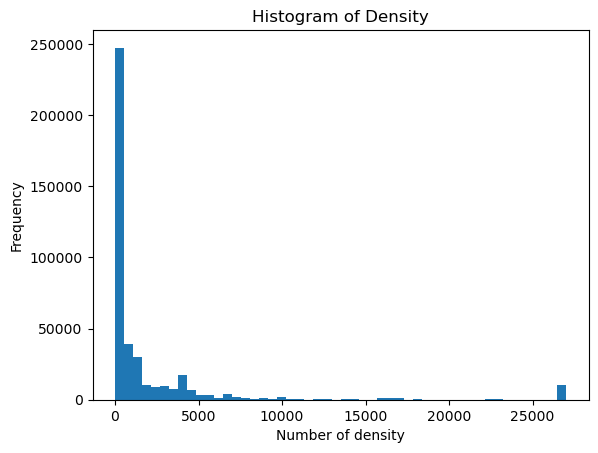

(np.float64(1985.1539128056559), 22812607.455827303)

In [24]:
import matplotlib.pyplot as plt

plt.hist(fr["Density"], bins=50)
plt.xlabel("Number of density")
plt.ylabel("Frequency")
plt.title("Histogram of Density")
plt.show()
mean_nb = fr["Density"].mean()
var_nb  = fr["Density"].var()
mean_nb, var_nb

In [29]:
fr['DensityBand'] = pd.cut(fr['Density'], bins = [1, 200, 1000, 2000, 5000, 27000], right = True)
(fr.groupby('DensityBand')["Exposure"].sum()/fr["Exposure"].sum())

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/250386575.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (fr.groupby('DensityBand')["Exposure"].sum()/fr["Exposure"].sum())


DensityBand
(1, 200]         0.484819
(200, 1000]      0.245230
(1000, 2000]     0.100552
(2000, 5000]     0.105705
(5000, 27000]    0.063694
Name: Exposure, dtype: float64

In [30]:
fr.groupby('DensityBand').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/2143031861.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fr.groupby('DensityBand').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())
/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/2143031861.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fr.groupby('DensityBand').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())


DensityBand
(1, 200]         0.057619
(200, 1000]      0.071345
(1000, 2000]     0.087086
(2000, 5000]     0.092838
(5000, 27000]    0.091022
dtype: float64

In [335]:
fr["PowerGroup"] = fr["Power"].where(fr["Power"].isin(list("defg")), other="Higher")
(fr.groupby('PowerGroup')["Exposure"].sum()/fr["Exposure"].sum())

PowerGroup
Higher    0.180420
d         0.163145
e         0.192540
f         0.241066
g         0.222829
Name: Exposure, dtype: float64

In [334]:
fr.groupby('PowerGroup').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/3373283332.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fr.groupby('PowerGroup').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())


PowerGroup
Higher    0.075551
d         0.062373
e         0.071714
f         0.071522
g         0.067058
dtype: float64

In [36]:
(fr.groupby('Brand')["Exposure"].sum()/fr["Exposure"].sum())

Brand
Fiat                                  0.041072
Japanese (except Nissan) or Korean    0.134839
Mercedes, Chrysler or BMW             0.045464
Opel, General Motors or Ford          0.094170
Renault, Nissan or Citroen            0.580648
Volkswagen, Audi, Skoda or Seat       0.078939
other                                 0.024869
Name: Exposure, dtype: float64

In [37]:
fr.groupby('Brand').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/2776540556.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fr.groupby('Brand').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())


Brand
Fiat                                  0.074988
Japanese (except Nissan) or Korean    0.066477
Mercedes, Chrysler or BMW             0.079035
Opel, General Motors or Ford          0.079292
Renault, Nissan or Citroen            0.066430
Volkswagen, Audi, Skoda or Seat       0.080328
other                                 0.071637
dtype: float64

In [38]:
(fr.groupby('Gas')["Exposure"].sum()/fr["Exposure"].sum())

Gas
Diesel     0.48789
Regular    0.51211
Name: Exposure, dtype: float64

In [39]:
fr.groupby('Gas').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/2774243461.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fr.groupby('Gas').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())


Gas
Diesel     0.074674
Regular    0.065154
dtype: float64

In [248]:
small_regions = [
    "Basse-Normandie",
    "Haute-Normandie",
    "Limousin"
]

fr["RegionGroup"] = fr["Region"].where(
    ~fr["Region"].isin(small_regions),
    other="LowerExposureRegion"
)

In [249]:
(fr.groupby('RegionGroup')["Exposure"].sum()/fr["Exposure"].sum())

RegionGroup
Aquitaine              0.061780
Bretagne               0.119718
Centre                 0.443064
Ile-de-France          0.130308
LowerExposureRegion    0.052762
Nord-Pas-de-Calais     0.049598
Pays-de-la-Loire       0.094615
Poitou-Charentes       0.048155
Name: Exposure, dtype: float64

In [44]:
fr.groupby('RegionGroup').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/3935952185.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fr.groupby('RegionGroup').apply(lambda g: g["ClaimNb"].sum() / g["Exposure"].sum())


RegionGroup
Aquitaine             0.073662
Bretagne              0.067415
Centre                0.063040
Ile-de-France         0.085770
Nord-Pas-de-Calais    0.082101
OtherRegion           0.071046
Pays-de-la-Loire      0.071852
Poitou-Charentes      0.071663
dtype: float64

In [339]:
#model setup
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
fr_model = smf.glm(
    formula = """
    ClaimNb ~ 
    C(DriverAgeBand) + 
    C(CarAgeBand) +
    C(DensityBand) +
    C(PowerGroup) +
    C(Brand) +
    C(RegionGroup)
    """,
    data = fr,
    family = sm.families.Poisson(),
    offset = np.log(fr["Exposure"])
).fit()

In [340]:
print(fr_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               413169
Model:                            GLM   Df Residuals:                   413139
Model Family:                 Poisson   Df Model:                           29
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67639.
Date:                Sun, 04 Jan 2026   Deviance:                   1.0402e+05
Time:                        13:12:38   Pearson chi2:                 7.19e+05
No. Iterations:                     7   Pseudo R-squ. (CS):           0.003845
Covariance Type:            nonrobust                                         
                                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [56]:
#delete predictor region-group model
fr_model2 = smf.glm(
    formula = """
    ClaimNb ~ 
    C(DriverAgeBand) + 
    C(CarAgeBand) +
    C(DensityBand) +
    C(PowerGroup) +
    C(Brand) 
    """,
    data = fr,
    family = sm.families.Poisson(),
    offset = np.log(fr["Exposure"])
).fit()

In [306]:
print(fr_model2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               413169
Model:                            GLM   Df Residuals:                   413146
Model Family:                 Poisson   Df Model:                           22
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67651.
Date:                Sun, 04 Jan 2026   Deviance:                   1.0404e+05
Time:                        12:45:36   Pearson chi2:                 7.20e+05
No. Iterations:                     7   Pseudo R-squ. (CS):           0.003788
Covariance Type:            nonrobust                                         
                                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [310]:
fr_model.aic, fr_model2.aic

(np.float64(135337.94287078088), np.float64(135347.80471455926))

In [308]:
fr_model2.aic - fr_model.aic

np.float64(9.86184377837344)

In [60]:
#delete brand model
fr_model3 = smf.glm(
    formula = """
    ClaimNb ~ 
    C(DriverAgeBand) + 
    C(CarAgeBand) +
    C(DensityBand) +
    C(PowerGroup) +
    C(RegionGroup)
    """,
    data = fr,
    family = sm.families.Poisson(),
    offset = np.log(fr["Exposure"])
).fit()

In [61]:
print(fr_model3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               413169
Model:                            GLM   Df Residuals:                   413145
Model Family:                 Poisson   Df Model:                           23
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67688.
Date:                Wed, 24 Dec 2025   Deviance:                   1.0412e+05
Time:                        14:05:39   Pearson chi2:                 7.15e+05
No. Iterations:                     7   Pseudo R-squ. (CS):           0.003610
Covariance Type:            nonrobust                                         
                                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [311]:
fr_model3.aic - fr_model.aic

np.float64(85.66897981314105)

In [312]:
#find Overdispersion,try negative binomial model
fr_nbmodel = smf.glm(
    formula = """
    ClaimNb ~ 
    C(DriverAgeBand) + 
    C(CarAgeBand) +
    C(DensityBand) +
    C(PowerGroup) +
    C(Brand) +
    C(RegionGroup)
    """,
    data = fr,
    family = sm.families.NegativeBinomial(alpha=alpha_hat),
    offset = np.log(fr["Exposure"])
).fit()

In [277]:
print(fr_nbmodel.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               413169
Model:                            GLM   Df Residuals:                   413139
Model Family:        NegativeBinomial   Df Model:                           29
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -67458.
Date:                Tue, 30 Dec 2025   Deviance:                       86140.
Time:                        23:26:38   Pearson chi2:                 6.87e+05
No. Iterations:                     7   Pseudo R-squ. (CS):           0.003590
Covariance Type:            nonrobust                                         
                                                              coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

In [276]:
#negative binomial dis. is better
fr_nbmodel.aic

np.float64(134976.77225403092)

In [313]:
fr_nbmodel.aic - fr_model.aic

np.float64(-361.1706167499651)

In [73]:
fr_nbmodel.llf - fr_model.llf
#log likelihood，nb better

np.float64(189.314737200315)

In [342]:
#analyze severity dataset
sev_raw = pd.read_csv("/Users/qiyuezhang/Downloads/project/freMTPLsev.csv")
#merge claim amount and frequency datasets
sev = sev_raw.merge(
    fr,                    
    on="PolicyID",
    how="left")

In [343]:
sev.describe(include='all')

,PolicyID,ClaimAmount,ClaimNb,Exposure,Power,CarAge,DriverAge,Brand,Gas,Region,Density,Driveragebond,DriverAgeBond,DriverAgeBand,CarAgeBand,DensityBand,PowerGroup,RegionGroup
count,16181.000000,1.618100e+04,16181.000000,16181.000000,16181,16181.000000,16181.000000,16181,16181,16181,16181.000000,16181,16181,16181,16181,16181,16181,16181
unique,NaN,NaN,NaN,NaN,12,NaN,NaN,7,2,10,NaN,6,6,6,4,5,5,8
top,NaN,NaN,NaN,NaN,f,NaN,NaN,"Renault, Nissan or Citroen",Diesel,Centre,NaN,"(45, 55]","(45, 55]","(45, 55]","(5, 10]","(1, 200]",f,Centre
freq,NaN,NaN,NaN,NaN,3997,NaN,NaN,8942,8446,6475,NaN,4022,4022,4022,5025,6476,3997,6475
mean,185015.202151,2.129972e+03,1.102342,0.707471,NaN,7.667697,44.862431,NaN,NaN,NaN,2113.642606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,117946.980398,2.106364e+04,0.326661,0.312215,NaN,5.243951,14.936110,NaN,NaN,NaN,4985.969633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,33.000000,2.000000e+00,1.000000,0.002740,NaN,0.000000,18.000000,NaN,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,83922.000000,6.980000e+02,1.000000,0.460000,NaN,3.000000,33.000000,NaN,NaN,NaN,84.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,169907.000000,1.156000e+03,1.000000,0.800000,NaN,7.000000,44.000000,NaN,NaN,NaN,388.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,281599.000000,1.243000e+03,1.000000,1.000000,NaN,11.000000,54.000000,NaN,NaN,NaN,1466.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


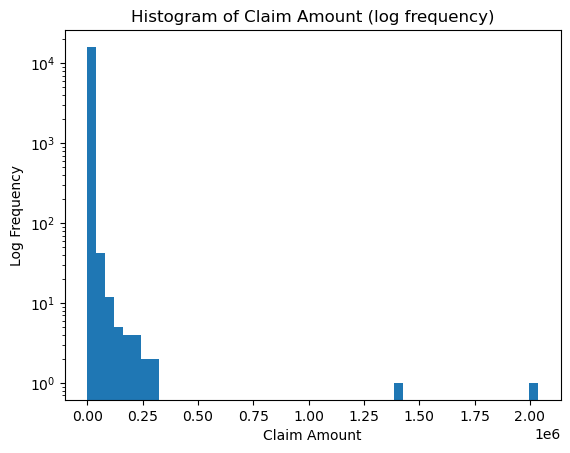

In [362]:
plt.hist(sev["ClaimAmount"], bins=50, log=True)
plt.xlabel("Claim Amount")
plt.ylabel("Log Frequency")
plt.title("Histogram of Claim Amount (log frequency)")
plt.show()
#gamma/lognormal
#highly right skewed

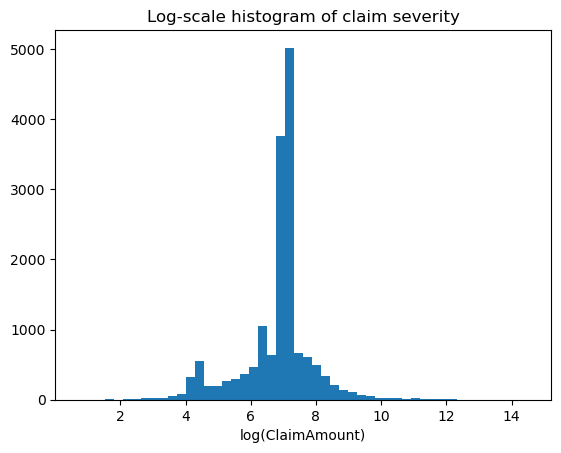

In [185]:
#after log_transformation,suitable for lognormal
import numpy as np
import matplotlib.pyplot as plt

plt.hist(np.log(sev["ClaimAmount"]), bins=50)
plt.xlabel("log(ClaimAmount)")
plt.title("Log-scale histogram of claim severity")
plt.show()

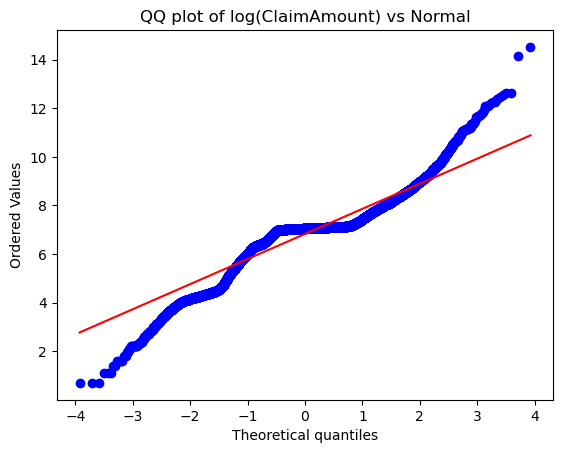

In [361]:
#check qq_plot for lognormal
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

y = sev["ClaimAmount"].values
logy = np.log(y)

st.probplot(logy, dist="norm", plot=plt)
plt.title("QQ plot of log(ClaimAmount) vs Normal")
plt.show()

In [79]:
#start to check and find dominate predictors
sev.groupby("CarAgeBand")["ClaimAmount"].median()

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/1523972473.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sev.groupby("CarAgeBand")["ClaimAmount"].median()


CarAgeBand
(-1, 2]      1161.0
(2, 5]       1160.0
(5, 10]      1151.0
(10, 100]    1156.0
Name: ClaimAmount, dtype: float64

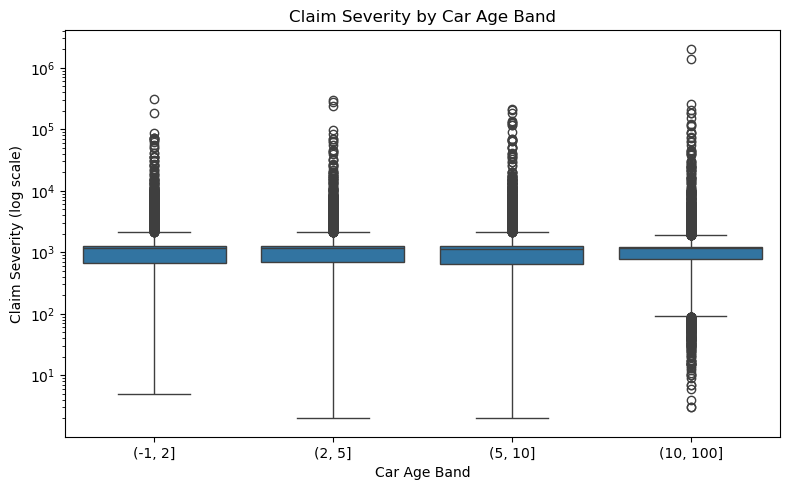

In [314]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(
    x="CarAgeBand",
    y="ClaimAmount",
    data=sev,
    showfliers=True   
)

plt.yscale("log")   
plt.xlabel("Car Age Band")
plt.ylabel("Claim Severity (log scale)")
plt.title("Claim Severity by Car Age Band")

plt.tight_layout()
plt.show()

In [89]:
sev.groupby("DensityBand")["ClaimAmount"].median()

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/3841220922.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sev.groupby("DensityBand")["ClaimAmount"].median()


DensityBand
(1, 200]         1153.0
(200, 1000]      1154.0
(1000, 2000]     1161.0
(2000, 5000]     1163.0
(5000, 27000]    1166.0
Name: ClaimAmount, dtype: float64

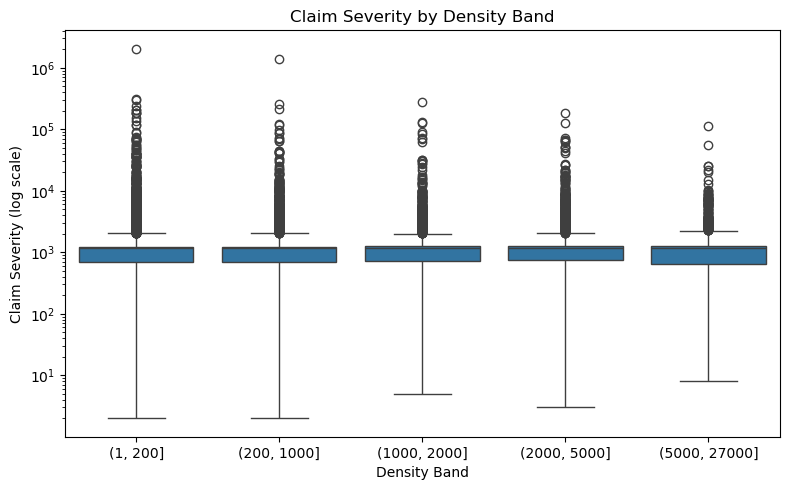

In [315]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="DensityBand",
    y="ClaimAmount",
    data=sev,
    showfliers=True   
)

plt.yscale("log")   
plt.xlabel("Density Band")
plt.ylabel("Claim Severity (log scale)")
plt.title("Claim Severity by Density Band")

plt.tight_layout()
plt.show()

In [81]:
sev.groupby("DriverAgeBand")["ClaimAmount"].median()

/var/folders/ww/zt40d1m513x5xlp4z9lqkscr0000gn/T/ipykernel_16838/2928310668.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sev.groupby("DriverAgeBand")["ClaimAmount"].median()


DriverAgeBand
(17, 25]     1163.0
(25, 35]     1146.0
(35, 45]     1152.0
(45, 55]     1154.0
(55, 65]     1165.0
(65, 100]    1167.0
Name: ClaimAmount, dtype: float64

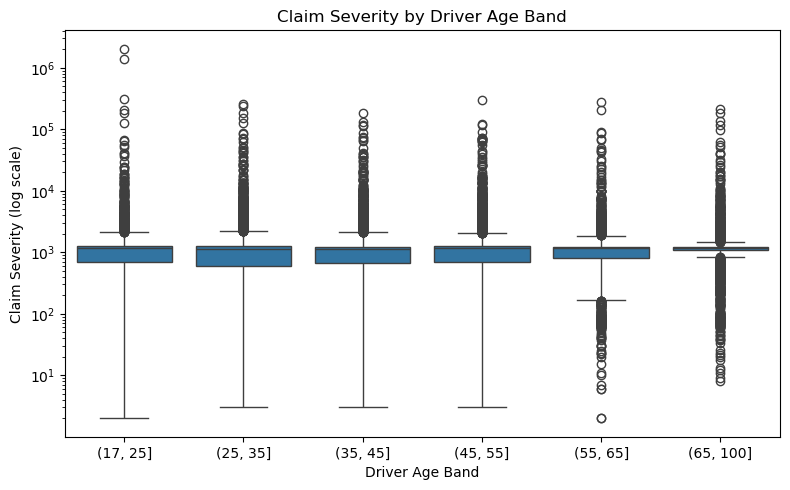

In [191]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="DriverAgeBand",
    y="ClaimAmount",
    data=sev,
    showfliers=True   
)

plt.yscale("log")   
plt.xlabel("Driver Age Band")
plt.ylabel("Claim Severity (log scale)")
plt.title("Claim Severity by Driver Age Band")

plt.tight_layout()
plt.show()

In [317]:
sev.groupby("PowerGroup")["ClaimAmount"].median()

PowerGroup
Higher    1165.0
d         1156.0
e         1155.0
f         1149.0
g         1156.0
Name: ClaimAmount, dtype: float64

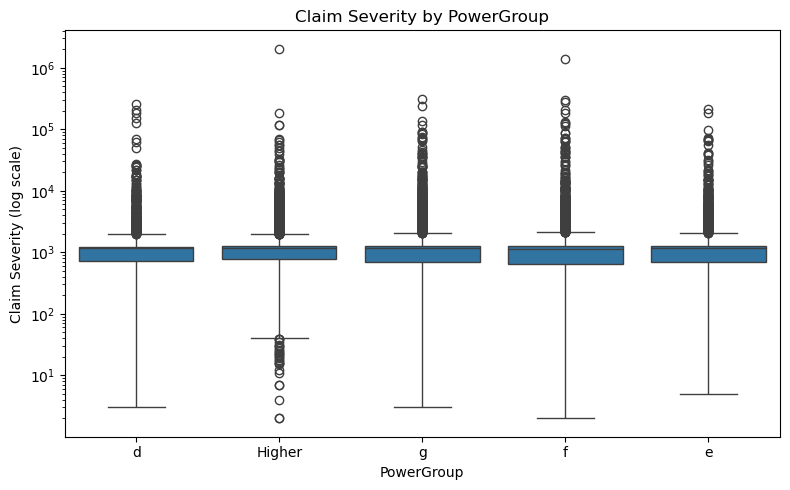

In [322]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="PowerGroup",
    y="ClaimAmount",
    data=sev,
    showfliers=True   
)

plt.yscale("log")   
plt.xlabel("PowerGroup")
plt.ylabel("Claim Severity (log scale)")
plt.title("Claim Severity by PowerGroup")

plt.tight_layout()
plt.show()

In [86]:
sev.groupby("Brand")["ClaimAmount"].median()

Brand
Fiat                                  1144.0
Japanese (except Nissan) or Korean    1191.0
Mercedes, Chrysler or BMW             1156.0
Opel, General Motors or Ford          1149.0
Renault, Nissan or Citroen            1151.0
Volkswagen, Audi, Skoda or Seat       1151.0
other                                 1162.0
Name: ClaimAmount, dtype: float64

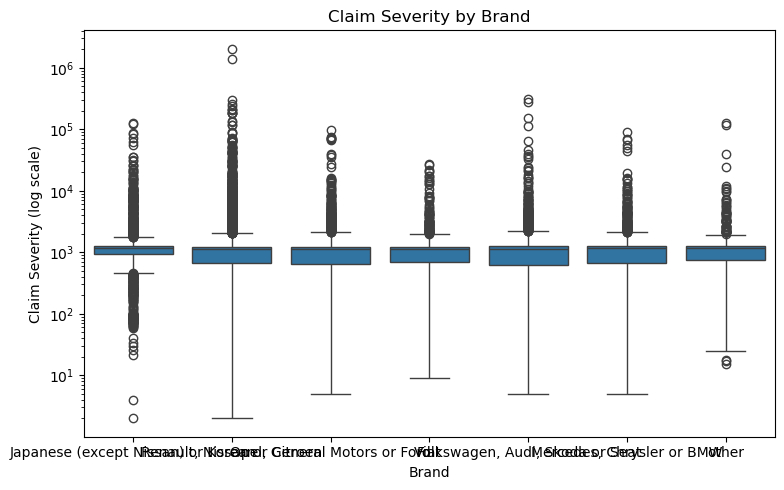

In [320]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="Brand",
    y="ClaimAmount",
    data=sev,
    showfliers=True   
)

plt.yscale("log")   
plt.xlabel("Brand")
plt.ylabel("Claim Severity (log scale)")
plt.title("Claim Severity by Brand")

plt.tight_layout()
plt.show()

In [328]:
sev.groupby("RegionGroup")["ClaimAmount"].median()

RegionGroup
Aquitaine              1165.0
Bretagne               1157.0
Centre                 1151.0
Ile-de-France          1171.0
LowerExposureRegion    1144.0
Nord-Pas-de-Calais     1170.5
Pays-de-la-Loire       1148.5
Poitou-Charentes       1153.0
Name: ClaimAmount, dtype: float64

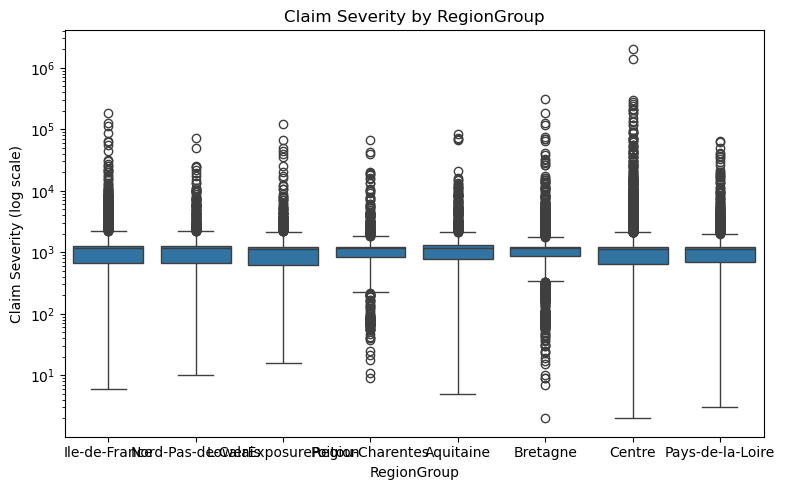

In [329]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="RegionGroup",
    y="ClaimAmount",
    data=sev,
    showfliers=True   
)

plt.yscale("log")   
plt.xlabel("RegionGroup")
plt.ylabel("Claim Severity (log scale)")
plt.title("Claim Severity by RegionGroup")

plt.tight_layout()
plt.show()

In [344]:
sev["ClaimAmount"].mean(), sev["ClaimAmount"].median()

(np.float64(2129.9720042024596), 1156.0)

In [363]:
#lognormal model
sev2 = sev.copy()
sev2 = sev2[sev2["ClaimAmount"] > 0].copy()
sev2["logClaim"] = np.log(sev2["ClaimAmount"])
sev_model = smf.ols(
    "logClaim ~ 1",
    data=sev2
).fit()
print(sev_model.summary())

                            OLS Regression Results                            
Dep. Variable:               logClaim   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 04 Jan 2026   Prob (F-statistic):                nan
Time:                        13:52:10   Log-Likelihood:                -24724.
No. Observations:               16181   AIC:                         4.945e+04
Df Residuals:                   16180   BIC:                         4.946e+04
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.8276      0.009    778.763      0.0

In [346]:
#gamma model
sev_df = sev.copy()
sev_df = sev_df[sev_df["ClaimAmount"] > 0]
gamma_model = smf.glm(
    formula="ClaimAmount ~ 1",
    data=sev_df,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()

print(gamma_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            ClaimAmount   No. Observations:                16181
Model:                            GLM   Df Residuals:                    16180
Model Family:                   Gamma   Df Model:                            0
Link Function:                    log   Scale:                          97.796
Method:                          IRLS   Log-Likelihood:            -1.8560e+05
Date:                Sun, 04 Jan 2026   Deviance:                       27064.
Time:                        13:20:39   Pearson chi2:                 1.58e+06
No. Iterations:                     8   Pseudo R-squ. (CS):              0.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.6639      0.078     98.580      0.0

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


In [348]:
sev_model.aic - gamma_model.aic

np.float64(-321753.27725545893)

In [349]:
#choose lognormal model
sigma2 = sev_model.mse_resid
sev2["sev_mean_pred"] = np.exp(sev_model.predict(sev2) + 0.5*sigma2)

In [350]:
#find parameter for montecarlo
mu_hat_sev = sev_model.params["Intercept"]
sigma_hat_sev = np.sqrt(sev_model.mse_resid)
mu_hat_sev,sigma_hat_sev

(np.float64(6.827584815579126), np.float64(1.1152302763020694))

In [351]:
mu_i = fr_nbmodel.predict(fr)
mu_i

0         0.050866
1         0.050866
2         0.081614
3         0.081614
4         0.047584
            ...   
413164    0.091730
413165    0.072748
413166    0.089542
413167    0.068775
413168    0.052892
Length: 413169, dtype: float64

In [279]:
mean = fr["ClaimNb"].mean()
var  = fr["ClaimNb"].var()
alpha_hat = max((var - mean) / (mean ** 2), 0)
alpha_hat, mean, var

(np.float64(1.613293963434657),
 np.float64(0.03916315115606447),
 0.04163754465805693)

In [280]:
# monte carlo for 10000 times
import numpy as np

rng = np.random.default_rng(42)
alpha = alpha_hat        # NB dispersion

n_sim = 10000
total_loss = np.zeros(n_sim)
total_claims = np.zeros(n_sim, dtype=int)

for s in range(n_sim):

    # 1) simulate frequency per policy (NB)
    N_i = rng.negative_binomial(
        n=1 / alpha,
        p=1 / (1 + alpha * mu_i)
    )

    N_tot = int(N_i.sum())
    total_claims[s] = N_tot

    # 2) simulate severity (Lognormal)
    if N_tot > 0:
        X = rng.lognormal(
            mean=mu_hat_sev,
            sigma=sigma_hat_sev,
            size=N_tot
        )
        total_loss[s] = X.sum()
    else:
        total_loss[s] = 0.0


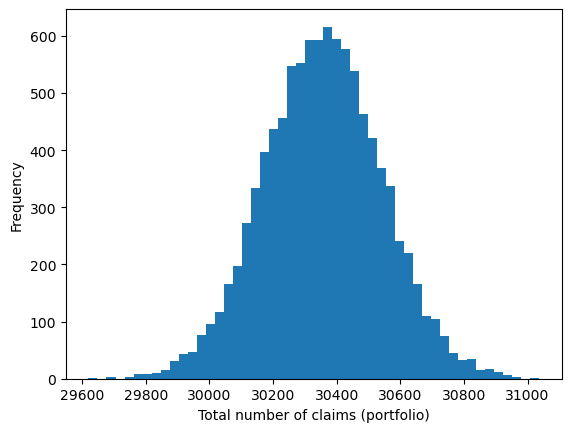

In [281]:
plt.hist(total_claims, bins=50)
plt.xlabel("Total number of claims (portfolio)")
plt.ylabel("Frequency")
plt.show()

In [352]:
VaR95 = np.quantile(total_loss, 0.95)
VaR99 = np.quantile(total_loss, 0.99)
VaR95,VaR99

(np.float64(53120260.22021383), np.float64(53495216.973082416))

In [287]:
ES95 = total_loss[total_loss >= VaR95].mean()
ES99 = total_loss[total_loss >= VaR99].mean()
ES95, ES99

(np.float64(53346475.66114168), np.float64(53651113.88203914))

In [288]:
pure_pre = total_loss.mean()
pure_pre

np.float64(52185158.75909561)

In [289]:
total_exposure = fr["Exposure"].sum()  

In [290]:
#rate per exposure
rate_pure  = pure_pre / total_exposure
rate_VaR = VaR99 / total_exposure
rate_ES  = ES99 / total_exposure
rate_pure, rate_VaR, rate_ES

(np.float64(225.10663694806036),
 np.float64(230.75772253961952),
 np.float64(231.43020164517995))

In [291]:
premium = rate_pure + 0.07*(rate_VaR - rate_pure)
premium

np.float64(225.5022129394695)

In [292]:
#risk_load
r = 0.07*(rate_VaR - rate_pure)
r

np.float64(0.3955759914091417)

In [293]:
#model validate
import numpy as np
import pandas as pd

np.random.seed(42)

u = np.random.rand(len(fr))

train_fr = fr[u < 0.7].copy()
test_fr  = fr[u >= 0.7].copy()

print(len(train_fr), len(test_fr))
print(len(train_fr) / len(fr))

289217 123952
0.6999968535877571


In [260]:
fr_nbmodel_train = smf.glm(
    formula = """
    ClaimNb ~ 
    C(DriverAgeBand) + 
    C(CarAgeBand) +
    C(DensityBand) +
    C(PowerGroup) +
    C(Brand) +
    C(RegionGroup)
    """,
    data = train_fr,
    family = sm.families.NegativeBinomial(alpha=alpha_hat),
    offset = np.log(train_fr["Exposure"])
).fit()

In [354]:
logsev = np.log(sev["ClaimAmount"])
mu_hat = logsev.mean()
sigma_hat = logsev.std(ddof=1)
sev_mean_model = np.exp(mu_hat + 0.5 * sigma_hat**2)

In [355]:
mu_train = fr_nbmodel_train.predict(train_fr)
EL_train = np.sum(mu_train * sev_mean_model) / train_fr["Exposure"].sum()
mu_test = fr_nbmodel_train.predict(test_fr)
EL_test = np.sum(mu_test * sev_mean_model) / test_fr["Exposure"].sum()
EL_train, EL_test

(np.float64(225.18201715818665), np.float64(225.4970477933778))

In [294]:
###after ev frequency reduction 17%
mu_EV = 0.83 * mu_i
##sev
import numpy as np
from scipy.stats import norm

anchor_q = np.array([0.10, 0.25, 0.50, 0.75, 0.90, 0.99])
anchor_delta = np.array([0.086, 0.057, -0.010, -0.094, -0.134, -0.150])
def delta_from_q(q):
    q = np.asarray(q)
    return np.interp(q, anchor_q, anchor_delta,
                     left=anchor_delta[0],
                     right=anchor_delta[-1])
def apply_quantile_shock_to_lognormal_samples(X, mu, sigma):
    z = (np.log(X) - mu) / sigma
    q = norm.cdf(z)                
    delta = delta_from_q(q)        
    scale = np.clip(1.0 + delta, 1e-6, None)
    return X * scale

In [295]:
import numpy as np

rng = np.random.default_rng(42)
alpha = alpha_hat  

n_sim = 10000
total_loss_ev = np.zeros(n_sim)
total_claims_ev = np.zeros(n_sim, dtype=int)

for s in range(n_sim):
    N_i = rng.negative_binomial(
        n=1/alpha,
        p=1/(1 + alpha * mu_EV)
    )
    N_tot = int(N_i.sum())
    total_claims_ev[s] = N_tot

    if N_tot > 0:
        X = rng.lognormal(mean=mu_hat_sev, sigma=sigma_hat_sev, size=N_tot)
        X_ev = apply_quantile_shock_to_lognormal_samples(X, mu_hat_sev, sigma_hat_sev)
        total_loss_ev[s] = X_ev.sum()
    else:
        total_loss_ev[s] = 0.0


In [296]:
VaR99_mod = np.quantile(total_loss_ev, 0.99)
ES99_mod = total_loss_ev[total_loss_ev >= VaR99_mod].mean()
VaR99_mod, ES99_mod

(np.float64(40161253.38229844), np.float64(40330800.57118924))

In [297]:
pure_pre_mod = total_loss_ev.mean()
pure_pre_mod

np.float64(39102722.08696456)

In [298]:
#rate per exposure
rate_pure_mod  = pure_pre_mod / total_exposure
rate_VaR_mod = VaR99_mod / total_exposure
rate_ES_mod  = ES99_mod / total_exposure
rate_pure_mod, rate_VaR_mod, rate_ES_mod

(np.float64(168.67405357805947),
 np.float64(173.24014910527393),
 np.float64(173.97151025090912))

In [299]:
premium_mod = rate_pure_mod + 0.07*(rate_VaR_mod - rate_pure_mod)
premium_mod

np.float64(168.9936802649645)

In [356]:
#risk_load after modification
r_mod = 0.07*(rate_VaR_mod - rate_pure_mod)
r_mod

np.float64(0.31962668690501206)

In [357]:
premium-premium_mod

np.float64(56.508532674505005)

In [359]:
r-r_mod

np.float64(0.07594930450412962)